# Chapter 13:  Image Representation by Feature Extraction 

As in our Human Visual System, Image Processing and Computer Vision algorithms receive visual data at the input and produce  visual information of several abstraction levels, at the output. Let us  summarize the major abstraction levels we studied so far, from the simplest  to more complex algorithms, shown in Figure 1. 

In this book, we started from a very low level image processing step, which involves **sampling and quantization** of a physical scene by an image acquisition device. This step shatters a physical scene into bits and pieces of pixels with a very low level of representation in terms of bits of pixels.

Once we capture a digital image of a real life phenomenon, the next abstraction level may be to enhance this image for accentuating a predefined set of visual properties, such as edges or smooth regions. **Image enhancement** techniques can be developed in both spatial and transform domains. In the spatial domain, we studied a very powerful mathematical tool, called  two-dimensional  convolution operation. Convolving an image with a mask outputs a filtered image, accentuating the characteristics of the mask. We have also seen some linear and nonlinear transformations, such as, point operations and histogram equalization which edits the color palette of an image, according to a predefined goal. A dual space for image enhancement is the frequency domain, where we can apply image enhancement operations in a space, spanned by Fourier, Hadamard, cosine or wavelet basis functions.


As the size of the image database grows exponentially with the availability of high quality and inexpensive image acquisition devices, compressing the images becomes a crucial issue in a wide range of application domains. This step involves reducing the amount of data without reducing the amount of information content of the image. Thus, it requires a measure for the information content of an image. At this point Shannon Information Theory provides us with a practical tool, called entropy, to measure the average amount of information carried by a pixel of an image.  In this context, we have seen basic **image compression** algorithms, which aim to reduce redundancies embedded in an image.  

In order to enhance the shapes of objects, we introduce  powerful tools of mathematical morphology, called Minkowsky operations. This set of operations enables us to shrink or enlarge the shapes of objects, close the bays and holes or prune the sharp corners of objects. Notice that at this abstraction level,  **morphological analysis**  describes visual concepts, such as bays, corners, holes etc.

**Segmentation** algorithms partition an image into a set of “homogenous” regions with respect to a similarity predicate or find the abrupt changes, with respect to a dissimilarity predicate. We segment an image into a set of homogenous regions, which can be later used for some computer vision tasks, such as object recognition, detection or classification. Therefore, this abstraction level can be considered as a borderline between the image processing and computer vision algorithms. Notice that  output of a segmentation algorithm does not have labels for the homogeneous regions or boundaries.


<figure><p  align="center"><img  src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W14/ipcv.png"  height=350px><figcaption>Figure 1: Levels of Abstraction for Image Processing and Computer Vision Algorithms. Green boxes indicate Image Processing methods, yellow boxes are the transition methods between Image processing and Computer Vision. Red boxes indicate the Computer Vision Algorithms. At the lowest abstraction level of sampling and quantization, an image is represented by a bunch of pixels, with color and coordinate index. At the next level, enhancement techniques extract low level information from the image, such as edges or smooth regions.  Compression allows us to represent the information content of an image with a relatively  lower number of bits. Morphological analysis enables us to  manipulate the shape properties, such as holes, bays and corners.  Segmentation and Feature Extraction steps are shared by both image processing and Computer Vision fields, which prepares the image for computer vision tasks such as object recognition, image understanding and interpretation. </figcaption></p></figure>


The above image processing techniques, until feature extraction receive a digital image at the input of an algorithm and output another image, such as, enhanced image, transform domain  image, the output of a morphological operation, a segmentation map, boundary overlays or an edge map.  

<figure><p  align="center"><img  src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W14/image2.png"  height=200px><figcaption>Figure 2: An outdoor scene (left) and its segmentation map (right).
(displayed in pseudo-color). (Adapted from Selim Aksoy)</figcaption></p></figure>

<figure><p  align="center"><img  src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W14/image1.jpg"  height=200px><figcaption>Figure 3: An outdoor image (left) and the boundary overlays of the segmented regions (right).
(Adapted from Selim Aksoy) </figcaption></p></figure>

At the output of a segmentation algorithm, the regions, boundary pixels  or group of pixels are not attributed to any meanings. A segmentation map, shown in  Figure 2 and 4, is just an array of numbers, which consists  of the region index of each pixel, together with the pixel coordinates.  Similarly, a boundary overlay, shown in Figure 3 and 5, is just another array of numbers which consists of the coordinates of boundary pixels.


<figure><p  align="center"><img  src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W14/image8.png"  height=200px><figcaption>Figure 4: Segmentation maps do not carry object labels. Does the orange area belong to the sea? Or does the green area belong to the forest?  (Adapted from Selim Aksoy)</figcaption></p></figure>

<figure><p  align="center"><img  src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W14/image7.jpg"  height=200px><figcaption>Figure 5: Overlays do not carry object labels. We do not know the boundaries on the sea correspond to the little waves of the lake.  (Adapted from Selim Aksoy) </figcaption></p></figure>


**Motivating Question:** Can we represent an image or its segmentation map  in a compact way other than array representation of indexed pixels  or boundary coordinates? Is it possible to represent the regions of an image or the image as a whole in higher abstraction levels compared to segmentation maps?  

The answer to the above questions lie in the heart of the image processing methods, called feature extraction. 

In this  chapter, we investigate the  highest abstraction level of the Image Processing methods, shown in the last yellow box of Figure 1, which is the exit to the high level Computer Vision Algorithms. At this abstraction level, we study the feature extraction techniques to describe  an image in a more informative and compact way. 

The major feature extraction techniques  can be studied under two headings:

**1. Region representation**  of a segmented image by
- shape features, such as length, curvature, convexities, etc.
- color and/or texture features, such as color histograms, Gabor filters and SIFT features etc.

**2. Whole image representation**  by high level information, such as, histograms, relational graphs, trees and statistical properties.

In the following subsections, we shall describe some popular feature extraction techniques for region and whole image representation.


## 1. Region Representation by Shape Features

Consider the output of a segmentation algorithm in the form of a boundary  overlay. Rather than storing the pixel coordinates of a boundary of a  region in an ordered set of strings, we can represent the boundary pixels in a more informative and compact way. There are dozens of shape descriptors in the Image Processing literature. Among them we suffice to provide the popular ones, as listed below:

1. Chain codes
2. Polygon approximation
3. Boundary segments
4. Signature
5. Skeletons
6. Fourier Descriptors
7. Shape Descriptors
8. Beam Angle Statistics (BAS)

In the following subsections, we shall briefly study region representation methods by shape features.


### 1.1. Chain Codes 

Chain coding techniques define a set of directional codes, called Freeman Chain Codes, to represent the boundary of a region by an ordered  string of integers, selected from an alphabet, as shown in Figure 6. 

<figure><p  align="center"><img  src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W14/image12.png"  height=200px><figcaption>

Figure 6: Two types of codes. 4-directional chain code with an alphabet,  $A=\{ 0, 1, 2, 3\}$ (left).  8-directional chain code with an alphabet, $A=\{ 0, 1, 2, 3,4, 5, 6, 7\}$ (right) . The integer values code the direction of the edge pixels with its neighboring pixels.</figcaption></p></figure>


The number of codes in the alphabet, depends on the defined neighborhood system. In a four-neighborhood system, there are four directional codes in the alphabet, $A=\{ 0, 1, 2, 3\}$  corresponding to right, up, left and down directions , respectively. In an eight-neighborhood system, there are eight directional codes in the alphabet, $A=\{ 0, 1, 2, 3,4, 5, 6, 7\}$ ,  corresponding to each angle between a center pixel and its eight neighbors. In order to limit the number of codes in the string, we can down-sample the image grid and then, we find the chain code representation of the boundary, as shown in Figure 7. 


<figure><p  align="center"><img  src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W14/image11.png"  height=400px><figcaption>

Figure 7: (a) Original Image. (b) Down-sampled version of the image in (a).  Starting from the upper left corner. (c) 4-directional chain code, $C =00333333221211101101$.  (d) 8-directional chain code: $C= 076666553321212$.(From Gonzales and Woods)</figcaption></p></figure>



Chain codes generate a string of integers for the region  boundary pixels. Although it is a very compact representation of a boundary, it has several problems: First of all, the generated string depends on the starting point. This is a serious problem, when we need to detect objects with similar shapes. In order to avoid this problem, we define the chain code as a circular sequence and we apply a cyclic string matching algorithm, which finds the best match between two circular sequences.  The second problem of the chain code representation is that the length of the string depends on the size object. Thus, the matching algorithms, which use the chain codes are not size independent. A simple approach to avoid the size variance is to normalize the length of the strings by changing the size of the sampling grid for each boundary. The third problem is the variation of the chain code with respect to rotation. When we rotate an object, we obtain a fully different chain code string. Thus, chain codes are not rotation invariant. In order to assure rotation invariance, we can use the  difference between the two consecutive codes, instead of the code itself.  For this purpose, we count the number of direction changes (in counter-clockwise direction)  between two adjacent elements of the code. 



For example; when we take the  difference between two consecutive codes of a 4-directional chain code string of $CC= 10103322$, we obtain  $CC_{dif} =31330303$. In order to keep the same number of codes in the difference chain code, we complete the cycle by taking the difference of the last code and the first code of the string.

**Exercise:** Given the boundary of an object, in Figure 8.a find its chain code representation and its rotation invariant version using 4- directional code.


<figure><p  align="center"><img  src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W14/image01.png"  height=200px><figcaption>Figure 8: a) Boundary of a region b) Four directional chain code.</figcaption></p></figure>


**Answer**: Starting from the upper left corner of the boundary, 4-Directional chain code of the shape is as follows:

$$CC = 00332121.$$


Obviously the above chain code representation changes when we rotate the object. In order to make the representation rotation invariant, we use the code differences in the counterclockwise direction,  between two consecutive codes and generate the following representation:

$$CC_{dif} =30303313.$$

In the above representation, we assume a circular string and take the difference between the last code and the first code to close the loop. 


**Exercise:** Starting from the lower left corner, find  a standard chain code and rotation invariant 4- directional chain code of the shape, given in Figure 9.

<figure><p  align="center"><img  src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W14/image6.png"  height=300px><figcaption>Figure 9: (a) Direction codes for chain code elements. (b) Chain code for the boundary shown. </figcaption></p></figure>

**Answer:** The standard 4-directional chain code is,

$$CC =1110101030333032212322$$
Rotation invariant 4-directional chain code is,

$$ CC_{dif} = 1003131331300133031130$$



### 1.2. Polygonal Approximations

The boundary representation of a region in a discrete grid can be considered as a polygon, where each boundary pixel corresponds to a vertex of this polygon.  However, the pixels which lie down on a straight  line, are redundant and can be eliminated.  Similarly, chain code representation of a boundary can also be considered as a polygon, considering the fact that the same consecutive codes lie down on a line. Thus, we can assume that a pixel corresponds to a vertex of the polygon if the chain code of the next pixel is different. However, one can represent a boundary with a smaller number of vertices compared to the chain code representation.

The goal of polygonal approximation methods is to capture the structure of the boundary shape with the fewest possible number of vertices. This representation can save space and simplify algorithms that process the boundary. There are a wide range of methods for polygonal approximation. As we have seen in Chapter 12, Hough transform can be used to fit a set of lines to an edge map without assuring a closed boundary. A post processing step is required to form a closed boundary from a bunch of line segments.

In the following, we shall briefly explain two simple polygon approximation methods.


**Polygonal Approximation by Merging**

The basic idea of polygonal approximation by merging is to eliminate the pixels, which are approximately  on the same line. 

A  simple method to fit a line to several pixels on the boundary is  the Least Squares  Method (LSM). This method estimates the parameters of a line equation, $y=ax+b$, which fits  to a set of pixels, with coordinates $\{x_i,y_i\}$ by minimizing the total square error between the sample points and the line equation. Mathematically speaking, it minimizes the sum of squared errors between the edge points and the fitted line equation,

$$L(a,b) = \sum_i  [y_i - (ax_i+b)]^2.$$


Taking the derivative of the cost function, $L(a,b)$  with respect to $a$ and $b$ and equating it to $0$  provides a closed form solution for finding the optimal parameters, $a$ and $b$

An iterative algorithm for polygon approximation  can be developed by using the Least Squares Method,  as follows:

**Algorithm: Polygon Approximation by Merging**

**Input:** Ordered set of boundary pixels with coordinates, $B=\{x_i,y_i\}$ , a predefined threshold value, $T$, an empty set, $P$.

**Output:** A set of vertices of a polygon, $P$.

Initialize with few consecutive pixels on the boundary.

**Step 1**: Put the arbitrarily selected few consecutive pixels  into the set, $P$.  

**Step 2**: Estimate $a$ and $b$  for the pixels in $P$ using the Least Squares Error Method and compute $L(a,b)$ for the pixels in $P$. 

**Step 3**: If  $L(a,b)\lt T$, transfer  the next pixel from $B$  to $P$  and go to step 2,

else label the last pixel in $P$ as a vertex, $v$ and  start a new subset in $P$. Go to Step 1.

**Step 4:** Stop, when all pixels are drawn from $B$.
 

At the end of the above algorithm, the intersections of adjacent line segments form the vertices of the polygon, as shown in Figure 10.


<figure><p  align="center"><img  src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W14/image16.png"  height=200px><figcaption>Figure 10: Several outputs of Polygon Approximation by merging method.  </figcaption></p></figure>

**Polygonal Approximation by Splitting**

Instead of merging the pixels into a line with Least Squares Error less then a predefined threshold, we can start from a line which fits the data with the largest error and keep splitting this line into segments until the error is less than a predefined threshold. An iterative algorithm based on the idea splitting is given below.

**Algorithm: Polygon Approximation with Splitting**

**Input:** Ordered set of boundary pixels with coordinates, $B=\{x_i,y_i\}$ , a predefined threshold value, $T$, an empty set, $P$.

**Output:** A set of vertices, $P$ of a polygon.

**Initialize:**  Find the longest line connecting two boundary points, $a,b$ and put pixels $a$ and $b$ in $P$.

**Step 1**: Find the maximum perpendicular distances, $D$,  from   line segment $ab$ to the farthest pixel, and label the pixel as $c.$ 

**Step 2**: If  $D \gt T$, then, split the line into two line pieces, $ac$ and $bc$ by merging the end points and  go to Step 1 to find the maximum distance between 
$ac$ and the boundary pixels, 
$bc$ and boundary pixels.
else stop.

**Step 3:** Set $ab:=ac$ and $ab=:bc$ and go to Step 1.

<figure><p  align="center"><img  src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W14/image17.png"  height=200px><figcaption>Figure 11:Polygon Approximation with Splitting. (a) Original boundary. (b) Boundary divided into segments based on extreme points. (c) Joining of vertices. (d) Resulting polygon. (From Gonzales and Woods) </figcaption></p></figure>


The splitting algorithm fits a polygon to a boundary of a convex region. Recall that a region is **convex** if  given any two points in the region, the line segment  joining them lies in that region. Otherwise the region is called **concave**. If the boundary consists of some concavities, we need to revise the above algorithm by splitting it into a set of convex boundary segments. 

**Motivating Question:** How can we partition a concave boundary into a set of convex segments?

Convexity is a very important concept in many fields of mathematics for finding  tractable solutions to a wide range of problems. In image processing, when a boundary is concave, the approximate analytical function, representing this boundary  becomes highly nonlinear. Thus,  most of the shape representation algorithms fail to estimate a compact form for concave shapes. Therefore, when  we design algorithms for shape representation it is very important to partition a concave shape into its convex components. As in the above polygon approximation algorithm, it is more practical to fit a polygon to a set of convex boundaries and then merge the convex polygons to form the boundary of a concave object. Furthermore,  the human visual system systematically partitions a concave object into a set of convex boundary segments and labels the convex segments as meaningful subparts of the objects. For example; a concave hand object consists of convex subparts called fingers. Similarly a concave daisy flower consists of convex petals.  Thus, when the boundary consists of concavities, it may be both practical and meaningful to segment the it into a convex set of segments. Then, we can fit a curve to each convex segment of the boundary to represent the concave shape by a collection of its convex parts.

Let us explore how we can partition a concave boundary into its convex segments.
 
### 1.3. Partitioning a Concave Boundary into a Set of Convex Boundary Segments

Suppose that we are given a concave region represented by an ordered set of boundary points. Our goal is to partition the boundary points into a set of convex segments. For this purpose, we employ two major geometrical concepts about a concave region, namely, convex hull and convex deficiency, as defined below.

**Definition: Convex Hull**, $H$ of an arbitrary region,  $R$, is the smallest convex set which contains the region.

**Definition: Convex deficiency** of the set $R$ is the set difference, $H-R.$



In order to partition a concave boundary into a set of convex boundary segments, first we find the convex hull. Then we find the convex deficiency. The transition points  between the convex hull and convex deficiency partition a concave boundary into a set of convex segments, as shown in Figure 12. 

<figure><p  align="center"><img  src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W14/image22.png"  height=300px><figcaption>Figure 12: (a) A region, S, and its convex deficiency (shaded). (b) Partitioned boundary. (From Gonzales and Woods)</figcaption></p></figure>


It is possible to revise the polygon approximation algorithms, mentioned above, to extract the convex hull, fat bit representation and minimum bounding rectangle of objects, as shown in Figure 13.

<figure><p  align="center"><img  src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W14/image18.png"  height=300px><figcaption>Figure 13: Rows show two different regions. Columns represent, from left to right: original boundary, smoothed polygon, convex hull, fat-bit representation, and minimum bounding rectangle. </figcaption></p></figure>



### 1.4. Signatures

If we can represent the boundary pixels by a one dimensional discrete function, then, we  can use the tools for measuring the distance between two functions, in calculus, to compare the boundaries. There are a variety of methods for representing the boundary of an object by discrete functions. One simple method is called the signature function.

Consider a set of $N$  boundary pixels, represented by the ordered pixel coordinates, $P=\{x_i, y_i\}_{i=0}^{N-1}$. Then, centroid of the boundary is defined as a two dimensional vector,

$$\bold m =[m_x \quad m_y] = \frac{1}{N} \sum_{i=0}^{N-1} [x_i \quad y_i],$$
where $m_x$ and $m_y$ are the coordinates of the centroid, $\bold m$.

Assume that the centroid is the origin of the coordinate system of the object, then, we can define the signature function,

$$r_i=f(\theta_i), \quad \text{for} \quad 0 \le \theta_i\le 2\pi$$ 

where $r_i$ is the distance of  the boundary pixel at coordinate, $(x_i,y_i)$ from the origin and $\theta_i$ is the angle between the starting pixel, $(x_0,y_0)$  of the boundary  and   $(x_i,y_i).$ 

As in chain code, the signature function is not invariant under rotation and size of the object. Additional preprocessing techniques are needed to normalize the signature function with respect to angle and scale. 

*<figure><p  align="center"><img  src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W14/image28.png"  height=300px><figcaption>Figure 14: Distance versus angle signatures.  (a) The signature function of a circle $r(\theta)$ is constant.  (b) The signature function of a square consists of repetitions of the same  pattern $r(\theta) = Asec(\theta)$ for $0\leq\theta\leq\pi/4$ and  $r(\theta) = Acsc(\theta)$ for $\pi/4\leq\theta\leq\pi/2$. (From Gonzales and Woods)</figcaption></p></figure>

Figure 14 shows the signature functions of a circle and square. Since the distance between the centroid and the points on the circle is the radius of the circle, the signature function is constant for all the angles. On the other hand, the signature function of a square  is maximum at the corners and minimum at the center of the edges.

<figure><p  align="center"><img  src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W14/image20.png"  height=300px><figcaption>Figure 15: An apple shape and its centroid distance signature. The starting point is at the top of the stem of the apple. </figcaption></p></figure>

Signature function provides substantial information about the shape and the size of the object. For example, the number of concavities or convexities can be characterized by the minima and maxima of the function. The maximum values of $r$ and the derivative, $\frac{ df(\theta)}{d\theta}$,  indicate the size  and smoothness of the boundary, respectively (see; Figure 15).


### 1. 5. Skeletons

In some applications, such as optical character recognition, technical drawings or microscopic images, the  structure of the object can be captured from its skeletons.

<figure><p  align="center"><img  src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W14/image32.png"  height=300px><figcaption>Figure 16: In the handwriting recognition problem, one needs to extract the boundary of the text.  </figcaption></p></figure>

In this case, the font or the size of the characters does not change the label of the character. In order to represent the structural shape of a region there are two widely used methods;
1. Medial axis transformation (MAT)
2. Thinning

In the following subsections let us briefly describe these techniques.

**1.5.1 Medial Axis Transformation (MAT)**

Medial Axis Transformation, extracts the skeleton of an object region by finding the set of points which are equidistant from the boundary.  The the steps of the algorithm is summarized below:

**Algorithm: Medial Axis Transformation**

**Input:** Ordered set of boundary pixels with coordinates, $P=\{x_i,y_i\}$ of a region $R$.

**Output:** A set of MAT pixels, $M$.

**Step 1:** For each pixel $p_i \in R$,  find the closest boundary pixel(s)   in $P=\{x_i,y_i\}$.
**Step 2:** If $p_i$ has more than one such neighbor, then transfer $p_i\in M$, else check it out. 
**Step 3:** Repeat step 2 until  $R$ is empty.

The above algorithm is very sensitive to noise and generates extra strokes when the boundary of the region is jiggly. As a result there may be superfluous joints, as depicted in Figure 17. 
	
<figure><p  align="center"><img  src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W14/image21.png"  height=300px><figcaption>Figure 17: Medial axes (dashed) of three simple regions. (From Gonzales and Woods) </figcaption></p></figure>

<figure><p  align="center"><img  src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W14/image24.png"  height=300px><figcaption>Figure 18:  A region, its skeleton, and the skeleton after filling the holes in the region.</figcaption></p></figure>



**1.5.2. Thinning**

In order to avoid the noise sensitivity of the MAT technique, we can peel the boundary, iteratively, until we get onew-pixel wide connected set of pixels. 

**Algorithm: Thinning**

**Input:** Region, $R=\{p_i\}$, a neighborhood system, $\eta(p_i)$, an empty set of trah, $T$.

**Output:** The set of skeleton  pixels, $S$.

For each iteration;

**Step1:** For each pixel, $p_i\in R$, check its neighborhood. If  at least one of the neighbors, $p_j \notin \eta(p_i)$, then remove it to thrash, $T$, else keep the pixel in $R$ and set $S=R.$
**Step 2:** Check the number of connected components in $R$. If there is more than one connected component, go to the previous iteration of $S=R$ and  stop, else, go to step 1.

The result of the thinning algorithm is shown in Figure 19. 

<figure><p  align="center"><img  src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W14/image27.png"  height=300px><figcaption>Figure 19: A letter and the output of the thinning algorithm. </figcaption></p></figure>




### 1. 6. Shape Descriptors

In some specific applications it is practical to measure a simple characteristic of a region to describe it.  For example, if we need to compare region size, all we need to know is the number of pixels in the regions of objects. There are dozens of shape descriptors in the Image Processing literature. Some popular ones are summarized below.
- **Area** is the total number of pixels in the region.
- **Perimeter** is the number of pixels  on the boundary. It is calculated by summing up the  pixels on the vertical and horizontal components and $\sqrt 2$ times the number of pixels on the diagonal components.
 - **Bounding box** is the smallest rectangle which covers the object (Figure 20).
- **Diameter** is the maximum distance between the boundary points.
- **Equivalent diameter** is the diameter of a circle with the same area as the region.

<figure><p  align="center"><img  src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W14/image33.png"  height=200px><figcaption>Figure 20: Bounding box (blue rectangle), diameter (the radius of the red circle) and equivalent diameter (radius of the green circle). </figcaption></p></figure>

- **Principal axes of inertia** is the major and minor axes of the ellipse, which covers the region. We can obtain the principal axes by simple Linear Algebra. First, we compute  the mean of pixel (Centroid) coordinates of the region, $R$ by
$$\bold m = \begin{bmatrix} m_x \\m_y \end{bmatrix} = \frac{1}{N}\sum_i \begin{bmatrix} x_i \\y_i \end{bmatrix},$$

where $N$ is the number of pixels in region $R.$ 

Then, we compute the $2\times 2$ covariance matrix of the region $R$ with the pixel coordinates, $\bold p_i = \begin{bmatrix} x_i \\y_i \end{bmatrix}$  by

$$Cov(R) = \frac{1}{N}\sum_i\sum_j [\bold p_i-\bold m][\bold p_j-\bold m]^T.$$
 


<figure><p  align="center"><img  src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W14/image33_2.png"  height=200px><figcaption>

Figure 21: Major and minor axes of the ellipse which cover  region $R.$ </figcaption></p></figure>


**Major axis** is the eigenvector of the covariance matrix corresponding to the larger eigenvalue and the **minor axis** is the eigenvector of the covariance matrix corresponding to the smaller eigenvalue. 

<figure><p  align="center"><img  src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W14/image34.png"  height=500px><figcaption>Figure 22: (a) An object, (b) Object showing eigenvectors of its covariance matrix. (c) Transformed object. (d) object translated so that all its coordinate values are greater than 0. (From Gonzales and Woods)</figcaption></p></figure>

$$\bold m=\begin{bmatrix} 3\\3 \end{bmatrix}$$
$$Cov(R) = \begin{bmatrix} 3.33\quad 2.00\\2.00 \quad 3.33 \end{bmatrix}.$$

The eigenvectors of the covariance matrix of the airplane region is then obtained
$$e_1=\begin{bmatrix} 0.707\\0.707 \end{bmatrix} $$
and
$$e_2=\begin{bmatrix} -0.707\\0.707 \end{bmatrix},$$

as the principal axes of the airplane.


- **Orientation** of a region is the angle between the  the major axis and the horizontal axis
- **Eccentricity** (elongation) of a region  is the ratio of the length of maximum chord (A)  
to minimum chord (B) perpendicular to A


<figure><p  align="center"><img  src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W14/image39.png"  height=150px><figcaption>

Figure 23: Eccentricity of a region is $A/B$. </figcaption></p></figure>

- **Compactness** is defined as the perimeter$^2$/ area  (minimized by a disk)
- **Extent** is the ratio of region/area of its bounding box
- **Solidity** is the ratio of region/area of its convex hull

- **Euler number** is  a topological property that describes the connectedness of a region. It is defined as 
$$E= \text{number of connected regions – number of  holes}.$$ 

- **Spatial Central Moments** represent  important characteristics of probability distribution of region coordinates. Formally, $ij$th moment of a region is defined as,

$$m_{ij} = \sum_i (x_i - m_x)^i(y_i-m_y)^j,$$
where

$$m_x = \frac{1}{n}\sum_i x_i$$
$$m_y = \frac{1}{n}\sum_i y_i.$$

Central moments measure  attractive properties of regions about how big is the region, how scattered the pixels are, how jiggly the boundary is etc. 

### 1.7. Fourier Descriptors

Consider a region boundary,  $B= \{(x_k, y_k)\}_{k=0}^{K-1},$ represented by an ordered set of two dimensional pixel coordinates, In this setup, each pixel coordinate can be treated as a complex number. Then, the boundary pixel coordinates are represented in the complex plane by a complex number as,
 $$z_k = x_k +j y_k \quad  \text{for } k =  0, 1 \ldots, (K-1].$$

Given the set of $K$ boundary points,  we can start at an arbitrary point and traverse the boundary in a particular direction. This defines the trajectory of a discrete complex function, which can be represented by discrete Fourier transform, as follows ;

$$z_k = \sum_{k=0}^{K-1} a_u e^{-2\pi juk/K},$$
where
$$a_u = \sum_{k=0}^{K-1} z_k e^{2\pi juk/K}$$


<figure><p  align="center"><img  src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W14/image03.jpg"  height=300px><figcaption> Figure 24:  A set of boundary pixels can be represented as complex numbers in the complex plane. </figcaption></p></figure>


The  coefficients $\{a_u\}_{u=0}^{K-1}$ of the discrete Fourier transform of the discrete boundary function, $\{z_k\}_{k=0}^{K-1}$ are called the **Fourier descriptors** of the boundary.

The inverse Fourier transform of the boundary points, $z_k$,  can be reconstructed from the coefficients, $a_u$, If only the first, $P$ coefficients, where  $L\lt K$, are used in the reconstruction, we obtain an approximation to the boundary trajectory.
- Note that only $P$ terms are used to obtain each boundary point, $z_k$, but $k$ still ranges from $0$ to $K-1$.
- Since the high frequency components of the Fourier transform account for fine detail, the smaller $P$ becomes, the more details are lost on the boundary (see: Figure 25).


<figure><p  align="center"><img  src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W14/image49.png"  height=400px><figcaption>Figure 25: Examples of reconstruction from Fourier descriptors. P is the number of Fourier coefficients used in the reconstruction of the boundary. (From Gonzales and Woods).</figcaption></p></figure>

Figure 26 shows a real life example of a microscopic image of a chromosome.The original image consists of 2868 pixel coordinates. If we use  72 Fourier descriptors to represent the shape, we can reconstruct the chromosome almost identically. In fact, reconstructing the chromosome with only 18 points, the shape  gets smoother. Thus, Fourier descriptors not only represent the boundary in a compact way, it also removes the undesired noise embedded in the boundary.

*<figure><p  align="center"><img  src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W14/image42.png"  height=400px><figcaption>Figure 26: (a) Boundary of human chromosome (2868 points). (b)-(h) Boundaries reconstructed using 1434, 286, 144, 72, 36, 18 and 8 Fourier descriptors respectively. These numbers are approximately 50\%, 10\%, 5\%, 2.5\%, 1.25\%, 0.63\%, and 0.28\% of 2868, respectively. (From Gonzales and Woods).</figcaption></p></figure>


### 1.8. A Perceptual Shape Descriptor: Beam Angle Statistics (BAS)

The representation power of the shape descriptors mentioned above depends on the pre-determined parameters. For example; selection of the number of Fourier descriptors, $P$, is a crucial issue. When the shape consists of  fine details, one needs to select a large $P$. On the other hand, for smooth and convex shapes a small number of descriptors is sufficient. Therefore, there is no universal method to determine the number for Fourier descriptors, which is valid for a wide range of shapes.

In this section, we introduce a statistical method for shape representation, which avoids the parameter selection problem. Let us start by defining the **beam angle** of a boundary point $p_i$.

**Definition:** Given an ordered set of boundary pixels, $B=\{p_0, p_1, ....,p_{N-1}\}$, **Kth degree beam angle** of a pixel is defined as the angle between the rays formed by $K$ pixel before and $K$ pixel after the vertex pixel, $p_i$,
$$C_K(i) = \angle (p_{i-K}, p_{i+K}).$$

Figure 27 shows the $K=5$th degree beam angle at vertex pixel, $p_i.$

Now, we define K-curvature, as follows.

**Definition:  K-curvature:** Given a set of boundary points, $B=\{p_0, p_1, ....,p_{N-1}\}$, K-curvature  is a mapping from the index of each pixel, $p_i$ to the corresponding $K$th degree beam angle, $C_K(i)$,

$$C_K : i \rightarrow C_K(i) , \quad \text{for} \quad  i= 0, 1,...,(N-1).$$

<figure><p  align="center"><img  src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W14/image44.png"  height=300px><figcaption>Figure 27: The 5-curvature and the beam angle at the neighborhood system 5 for the boundary point p(i).</figcaption></p></figure>

**Definition:  K-Curvature:** Given a set of boundary points, $B=\{p_0, p_1, ....,p_{N-1}\}$, K-curvature  is a mapping from the index of each pixel, $p_i$ to the corresponding $K$th degree beam angle, $C_K(i)$,

$$C_K : i \rightarrow C_K(i),$$

where the domain is a set of integers, $i= 0, 1,...,(N-1)$ and the range is, $0 \le C_K(i) \le2 \pi.$



<figure><p  align="center"><img  src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W14/image48.png"  height=400px><figcaption>Figure 28: (a) A sample shape boundary and K-curvatures for (b) K=N/50, (c) K=N/10, (d) K=N/5 and (e) the superposition of K=N/50,... N/5 from top to bottom respectively. </figcaption></p></figure>

Figure 28 shows the K- curvature of a  boundary of a bird object, for various values of $K$. Notice that as the value of $K$ increases, the fine details of the boundary gets smoother. If we plot  K-curvatures for all possible K-values, we obtain a coarse to fine representation of the boundary, as shown in Figure 28.e. In order to aggregate the K- curvatures for  $K= 1,...N/2$ values, we can take the average of curves over all K-values, and obtain a **mean-curvature**. This one dimensional discrete function represents the set of boundary pixels without a need for parameter selection. 


In most practical problems, it is sufficient to store the pixels with local maxima and minima to represent the shape of an object. Obviously, for smooth boundaries the number of local maxima and minima will be low. For relatively jiggly boundaries, we get  a   higher number of local maxima and minima points to represent the boundary. The pixels at local maxima and minima can be considered as the vertices of the polygon, which approximates the boundary. Thus, BAS can be considered as a polygon approximation method. On the contrary of the above split or merge methods for polygon approximation, BAS does not rely on any predefined thresholds

If we need to capture all the information embedded in a shape we can define the boundary as the outcome of a probabilistic source, represented by a random variable, $C_K(i)$ . Specifically, at each pixel index, we can  define Kth beam angle, $C_K(i)$,  as a random variable for all $K= 1, 2, …, N/2$ values. Then, in addition to the mean curvature, we can estimate higher order moments of the K-curvature. Figure 29 shows the first three moments of the K-curvature of the bird shape of Figure 28. Note that, the third moment of the K-curvature is very close to each other, showing that the first two moments carry almost all of the information about the shape.


<figure><p  align="center"><img  src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W14/image55.png"  height=200px><figcaption>Figure 29: Third order statistics of beam angle for the shape in Figure 28. The bottom function is the mean-curvature. The second and third moment-curvatures are very similar to each other, which shows that the second order statistics is sufficient to represent this boundary. </figcaption></p></figure>

Due to the averaging process, mean curvature is very robust to noise. Figure 30 shows the mean curvature of  a boundary and its noisy versions are very close to each other. 


<figure><p  align="center"><img  src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W14/image50.png"  height=400px><figcaption>Figure 30: The BAS descriptor tested under noise. (a) Original shape.  (b) The noisy shape. Comparison of original and noisy shape represented by (c) curvature plot, and the BAS plot (d) mean curvature (e) second moment-curvature, (f) third moment curvature. </figcaption></p></figure>

## 2. Region Representation with Color and Texture Features

In the previous section, we represent the region boundaries by a feature vector, which describes  the shape properties. In this section,  we represent the inside of a region by a feature vector.

Formally, given a collection of pixels of a region, $R =\{p_i\}$, where each pixel, $p_i$ has a location and color information, we may represent a region by a d-dimensional feature vector, $f_{R} = [f_1 \  f_2\ ……f_d]$ , in a compact way by extracting some color or texture properties of the region. For example, the sky and sand regions of Figure 31 can be represented by a feature vector, where each entry is the average color values concatenated with the color variances in an HSI color space.
	
<figure><p  align="center"><img  src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W14/image58.png"  height=250px><figcaption>

Figure 31: The output of a segmentation algorithm has two regions, corresponding to the sky and sand. Our goal is to represent these  regions by vectors of $f_{sky}$ and $f_{sand}$, in a compact way.</figcaption></p></figure>


### 2.1. Color Features

Color features are based on the color histograms or the statistics of color histograms in space or transform domains, such as Fourier, Wavelets, Hadamard etc. 

Recall that the normalized color histogram of a region approximates the probability mass function for the color distribution of that region and it is is defined as,

$$p_R(c_k) = \frac{n_k}{N_R},$$

where $n_k$ is the number of pixels with color $c_k$ and $N_R$ is the total number of pixels in region $R.$ Once we obtain the normalized K-bins color histogram, we can represent region R by a vector, where the entries correspond to the relative frequency of  the color of each bin,
$$f_R =[p_R(c_1) \quad  p_R(c_2).........p_R(c_K)].$$

Moments and/or central moments of the normalized color histogram provides important information about the color content of a region. For example,  the first moment of the color histogram,

$$\mu_R = E(c_k)=\sum_{\forall k} c_k  p_R(c_k),$$
 
shows the **mean** color of the region, $R$, where $E$ indicates the expected value operator. 
 
Second central moment, which is the color **variance**
$$\sigma_R^2 = E[(c_k-\mu_R)^2]= \sum (c_k - \mu_R )^2 p_R(c_k) ,$$
measures the amount of scatter from the mean color.
 
In general, we can define **$m^{th}$ central moment** of the normalized color histogram for region $R$,
 
$$\mu_R^m = E[(c_k-\mu_R)^m] = \sum_{\forall k} (c_k - \mu_R )^m  p_R(c_k) ,$$
 
and form a feature vector to represent a region with its central moments, as follows;
$$f_R = [\mu_R  \quad  \mu_R^2  \quad  \mu_R^3…..\mu_R^M].$$ 
 
In most of the problems, second order statistics is sufficient to represent a region with its mean and variance, where we take $M=2$. A practical approach is to form a feature vector of 2-dimensions with mean value and the  **standard deviation**, $\sigma$, which is the square root of the variance.
 
 For example, consider the segmentation map, shown in Figure 32. The histograms of two regions, mean values and standard deviations of the regions, which belong to the lake,  are very close to each other, as shown in Figure 33. Thus, rather than representing the regions with K-dimensional feature vectors of bin relative frequencies of the histogram, we can use two-dimensional feature vectors with the mean and standard deviation of regions, in a compact way.


<figure><p  align="center"><img  src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W14/image67.png"  height=400px><figcaption>Figure 32: Segmentation map of an outdoor image, represented by boundary overlay.</figcaption></p></figure>

<figure><p  align="center"><img  src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W14/image60.png"  height=400px><figcaption>Figure 33: Histograms and second order statistics (mean values and variances) of regions which belong to the lake.</figcaption></p></figure>

Similarly, the regions which belong to the sky and forest of the scene of Figure 32 have discriminative histograms and second order statistics, as shown in Figure 34. Thus, it is practical to represent these regions by 2-dimensional vectors of mean value and standard deviation.

<figure><p  align="center"><img  src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W14/image61.png"  height=400px><figcaption>Figure 34: Histograms and second order statistics</figcaption></p></figure>

### 2.2. Texture Features

The Human Visual System perceives the objects with spatial variations of color and light intensity. These variations generate structural or statistical patterns on a collection of pixels in a digital image. Loosely speaking,  texture refers to the patterns, which appear on  the object surface, generated by the  characteristics of the material and illumination conditions. 

Recall that the smallest element of a two dimensional image is called **picture element**, in short **pixel**. Similarly, the smallest element of a three dimensional image is called **volume element**, in short **voxel**. Since textures describe the spatial relationship among the pixels or voxels, we need a collection of pixels or voxels to represent texture. This  **texture element** is called **texels**. Figure 35 shows some texels of natural textures.


Extracting texture features to represent an object is very crucial in many applications

Unfortunately, there is no mathematical definition of texture. However, a formal model for texture is expected to  quantify some properties of  texels, such as smoothness, roughness, coarseness, softness, regularity etc. 

**Motivating Question:** How do we represent and quantify some properties of texels?

There is no unique answer to the above question. However, depending on the application domain we can suggest  mathematical tools to measure some properties of texture. In this book we overview some popular texture representation techniques:
1. Autocorrelation Functions
2. Co-occurrence Matrices
3. Gabor Filters
4. Scale Invariant Feature Transform (SIFT)
5. LBP patterns


<figure><p  align="center"><img  src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W14/image86.png"  height=400px><figcaption>Figure 35: Texels are small image patches, which covers the pattern of spatial relationship among the pixels. </figcaption></p></figure>

#### 1. Autocorrelation Function

Recall that, in Chapter:9 we defined the  autocorrelation function of an image $f(x,y)$ as,

$$R(x,y) = \frac{1}{NM} \sum_{\forall k} \sum_{\forall l} f(k,l)f(x+k, y+l), \quad \forall (x,y),$$
 
to measure the correlation of an image with itself to measure the redundancies among the pixels. When the autocorrelation function is flat it shows that the pixels with the same color repeats itself. As the variation of pixel colors increases in a neighborhood the autocorrelation function is shaped by more  hills and valleys. When a texel has small granularities, the $R(x,y)$ function decreases rapidly with respect to $(x,y)$ For texels with large granularity, $R(x,y)$  decreases slowly. For texels which contain periodic patterns, $R(x,y)$  becomes periodic. In summary the analytical structure of the autocorrelation function provides information about the type of textures.
 


#### 2. Co-Occurrence Matrix

The relationship among the pixels can be modeled by defining position operators. A position operator is a pair of two neighboring pixels, as shown in Figure 36.

<figure><p  align="center"><img  src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W14/image62_tolu.png"  height=100px><figcaption>Figure 36: Examples of position operators for measuring vertical, horizontal and diagonal relationships among two neighboring pixels. </figcaption></p></figure>



1. Define a position operator, $P$, as relative position of a pixel, $p_i$ with color $c_i$ with respect to that of its neighbor $p_j$ with color $c_j$, where $p_i$ and $p_j$ are two neighboring pixels, $p_i\in \eta(p_j).$

2. Define the probability of a position operator in an image as
$$g_{ij}= Prob( \text{co-occurrence of }(c_i,c_j) \text{ with respect to }P)$$

3. Form the co-occurrence matrix $G = [g_{ij}]$, for all possible color pairs. For example; given a 2-bits/pixel image of size $N\times M$, there are a total of $(N-1)\times M$ horizontal position operators and a total of $4^2$ possible color pairs.

**Example:** Find the co-occurrence matrix of the following 2 bits/pixel matrix, defined over a horizontal position operator.
 
<figure><p  align="center"><img  src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W14/image63.png"  height=250px><figcaption>Figure 37:  A sample image with a horizontal position operator. matrix</figcaption></p></figure>

**Answer:** This is an image of size ….$5 \times 6$. Thus, there are a total of 30 horizontal position operators (horizontal pixel pairs). The possible color pairs for the  image  are:

$$(c_i,c_j) = \{ (0,0), (0,1), (1,1), (1,2), (2,0), (2,2), (2,3), (3,0), (3,3)\}$$

Co-occurrence matrix  for the image $f(x,y)$ is, 

$$G =\frac{1}{30}\begin{bmatrix} 5 \ 2 \ 0 \ 0 \\ 0 \ 4 \ 3 \ 0 \\ 2 \ 0 \ 6 \ 2 \\ 1 \ 0 \ 2 \ 3\end{bmatrix}.$$

The co-occurrence matrix of the above 2-bits/pixel image consists of all possible color pairs, which is $4^2 = 4\times 4.$

**Motivating Question:** What type of information does a co-occurrence matrix provide us about the texture of the image? 

The entries of the co-occurrence matrix provide us the relative frequency of a pixel color pair in the image with respect to the position operator. For example; the most frequent color pair of the above image is two horizontal black pixel pairs [0,0], in the upper left corner of the co-occurrence matrix. Also, a high trace of the co-occurrence matrix indicates a relatively smooth image. It is possible to define co-occurrence matrices with respect to a variety of  position operators of large sizes. 


#### Texture Descriptors Based on Co-Occurrence Matrix

Co-occurrence matrix, defined above, has too many entries to analyze and derive a conclusion about the texture of an image, especially when the number of colors in an image is high. For example,  for an 8-bits/pixel  image the size of the co-occurrence matrix is $256\times 256$. Thus, one needs to define measures and quantify the texture structure in a more compact way. In the following, we summarize some texture measures, extracted from the co-occurrence matrix.

1.  **Entropy**: As we have seen in Chapter 10, the entropy of a random process described by a random variable and its corresponding probability distribution, measures the amount of information embedded in the process and it is inversely proportional to the  degree of randomness.  Now, let us define the random variable as the co-occurrence of color pairs $(c_i,c_j), \forall (i,j)$ with respect to a position operator, $P$. The corresponding probability mass function  can be approximated by  $g_{ij}$. Then, the entropy of the co-occurrence of colors can be defined as, 

$$H = -\sum_{\forall i} \sum_{\forall j}  g_{ij}\log  g_{ij}.$$

Note that for large entropy values, the image looks very random, such as a salt and pepper noise. As the entropy decreases we observe more and more structural patterns  of texture in the image.

2. **Energy**: Let us assume that the entries of the co-occurrence matrix is a two dimensional signal, $g{ij}$$. Then, the energy of this signal is defined as,

$$E= \sum_{\forall i} \sum_{\forall j}  g_{ij}^2.$$

When the energy of a signal is high, it becomes homogeneous. As the energy decreases the texture becomes more and more heterogeneous.

3. **Contrast**: Contrast is a very important  texture characteristics of an image and it can be quantified by the following contrast measure:

$$C =  \Sigma_{\forall i} \Sigma_{\forall j} (p_i -  p_i)^2g_{ij}.$$

Note that when C is 0, then  $p_i =p_j, $ revealing  a constant color. As we obtain larger and larger contrast values, the image consists of high contrast pixels.

4. **Maximum probability**: The highest value of the co-occurrence matrix shows the most dominant color pairs in the image and it is measured by
$$\max_{i,j}\{g_{ij}\}.$$

The above texture measures can be calculated in the scale space, where images of the same scene are generated in multiple resolutions by downsampling a high resolution image. Then, it is possible to extract the  texture  features from the images of multiple resolutions. Recall that representation of objects and their structures heavily depends on the image resolution. Fine textures, such as the texture of the buildings in satellite images can be captured in high resolution images. On the other hand, in order to detect the relatively coarse textures, such as cities, we need to employ relatively low resolution images. In texture analysis, selection of the resolution is a crucial issue and it depends on what we are looking for in the images.


#### 3. Gabor Filters

One of the most important tools for texture analysis is the Gabor filters, suggested by  Dennis Gabor, in 1946 . It generates a texture alphabet of masks by defining textured patches in different frequencies and orientations. Then, it filters the image by these predefined masks to detect the textures of the masks in localized regions. 

Recently, neuroscientists show that Gabor filters resemble the operation characteristics of simple cells in the visual cortex of Human brain.  These cells are devoted to  texture representation and discrimination. Thus, texture analysis by using the  Gabor filters is considered to be compatible with human perception of texture.
 
Gabor Filters have well-defined analytical forms. Mathematically speaking, a 2-dimensional Gabor function is a Gaussian mask modulated by a sinusoidal waveform, defined below;  

$$g(x,y) = \frac{1}{2\pi\sigma_x\sigma_y}\exp \left[ -\frac{1}{2} \left( \frac{x^2}{\sigma^2_x} + \frac{y^2}{\sigma^2_y} \right) + 2\pi j Wx\right]$$


and its  Fourier Transform is
$$G(u,v) = \exp\left( -\frac{1}{2} \left[ \frac{(u-W)^2}{\sigma_u^2}+\frac{v^2}{\sigma_v^2}\right] \right),$$

where $W$ is a predefined frequency parameter. The standard deviations of the Gaussian functions in space and frequency domains are related by
$$\sigma_u = \frac{1}{2\pi\sigma_x},$$
and
$$\sigma_v = \frac{1}{2\pi\sigma_y}.$$

It is possible to show that  the Gabor function minimizes the uncertainty in 2-dimensional space. In other words, the entropy of the Gabor function is minimal compared to a large family of functions.

It is possible to generate a set of Gabor masks in K- different orientations for $\theta = n\pi/K,$ by rotating the $x$ and $y$ coordinates as follows;
$$x\rightarrow xcos\theta +ysin\theta$$
and
$$y\rightarrow -xsin\theta +ycos\theta.$$

 We can also change the parameters, $W$, $\sigma_u$ and $\sigma_v.$  Figure 43 shows the real part of a typical Gabor function and its cross sections with different orientation, $\theta$,  bandwidth, $W$ and $\sigma_u = 1/2\pi\sigma_x$ and $\sigma_v =  1/2\pi\sigma_y$. Note that the frequency parameter, $W$ defines the coarseness of the texture, whereas the standard deviation parameter, $\pi\sigma_x$ and $\pi\sigma_y$ define the spread of the Gaussian function.

The Gabor function defined above has very nice properties. For example; the Gabor function  in the Fourier domain preserves the exponential form. Although the analytical structure  of Gabor functions are the same in both domains, the space domain Gabor function is complex, whereas the frequency domain Gabor function is real.

In Image Processing and Computer Vision literature there are a variety of forms for Gabor functions. A popular version of 2-dimensional real Gabor function is defined as,

$$g(x,y) = \frac{1}{2\pi\sigma_x\sigma_y} \exp \left[ -\frac{1}{2}\left(\frac{x^2}{\sigma^2_x} + \frac{y^2}{\sigma^2_y} \right)\right] \cos 2\pi Wx$$

and its Fourier transform is


$$G(u,v) = \exp\left[ -2\pi^2 [ (u-W)^2\sigma_x^2+v^2\sigma_y^2]\right] + \exp\left[ -2\pi^2 [ (u+W)^2\sigma_x^2+v^2\sigma_y^2]\right].$$

Figure 38 shows the above real Gabor function in the space domain and its cross section, where each value of $g(x,y)$ is depicted by gray scale image mask. 


<figure><p  align="center"><img  src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W14/gabor.jpg"  height=350px><figcaption>
Figure 38:  A 2-dimensional real Gabor function and its cross section depicted with grayscale.  </figcaption></p></figure>







As we did in the complex Gabor function, by rotating the $x$ and $y$ coordinates with the angle $\theta$;
$$x\rightarrow x\cos\theta +y\sin\theta$$
and
$$y\rightarrow -x\sin\theta +y\cos\theta,$$

It is possible to generate a set of Gabor filter masks in K- different orientations for $\theta = n\pi/K.$ Similarly, we can change the frequency parameter, $W$ , to generate a variety of Gabor filters with different coarseness.

<figure><p  align="center"><img  src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W14/image77.png"  height=300px><figcaption>Figure 39: A set of Gabor filters used for texture extraction  (D. Gabor 1900-1979). Filters in various directions and resolutions are very successful in edge detection.</figcaption></p></figure>

Figure 39 shows a typical set of real Gabor filters, used for detecting the edges in different thickness and orientation. The filter outputs are compatible with human perception as we can also discriminate the edges and boundaries by their thickness and orientation for a fixed standard deviation, $\sigma_x = \sigma_y = \sigma$.


#### 4. Scale Invariant Feature Transform (SIFT)

Given a digital image, some  pixels may  carry more information about the image content, compared to the rest of the pixels. For example: the pixels corresponding to four corners of a door object in an image is very crucial to detect the door. Most of the time, these types of salient points are invariant with respect to scale, rotation and translation of the object. Intuitively, it is expected that these salient points are preserved in the images at multiple scales of resolution and it should be independent of size, translation and rotation of the object. It should be robust under small deformations, such as affine transforms and poor illumination conditions.

Scale Invariant Feature transform (SIFT), suggested by D. Lowe, is  one of the popular techniques for detecting  the salient points, called key points. It, also, extracts  local features from a small image region around each key point. SIFT  features are invariant to orientation, scale, illumination, small noise and blur. There are four major steps to extract SIFT features:

**Step 1**: Scale Space Extrema Detection 

**Step 2**: Key Point Localization

**Step 3**: Orientation Assignment

**Step 4**: Key Point Description  

In the following, we explain the above mentioned steps:

**Step 1: Scale Space Extrema Detection** 

The goal of this step is to identify the approximate locations and scales of the key image points, called scale space extrema. Recall that convolving an image, $f(x,y)$ with a Gaussian filter,

$$G(x,y;\sigma)= \frac{1}{\sqrt{2\pi}\sigma}exp[-\frac{1}{2\sigma^2}(x^2+y^2)],$$

blurs an image. The degree of the blur depends on the scale parameter, $\sigma$. As the scale gets larger, the output of the convolution,  $\hat{f}(x,y;\sigma) = G(x,y;\sigma)*f(x,y)$ gets more and more blurry. 

Now, let us define **Difference of Gaussian (DoG)** between two filtered images obtained at the output of convolving the image with two Gaussian functions at different scales, $\sigma$ and $k\sigma$, as follows:

$$D(x,y; k\sigma) =f(x,y) * G(x,y;\sigma) -f(x,y)*G(x,y;k\sigma) = f(x,y)*[G(x,y;\sigma)- G(x,y;k\sigma)],$$

where $k$ is an empirically determined parameter, which depends on the goal and application domain.  The DoG filter, $(G(x,y;\sigma)- G(x,y;k\sigma)),$ approximates the Laplacian of Gaussian filter which is widely used for edge detection. 


The output of the convolution of image in Figure 40 a, with two different scales, $\sigma=1$ and $k\sigma=2$ is shown in Figure 40. b and c. The difference between the two outputs is Shown in figure 40. 




Figure 40: a) An original image, b) output of the convolution $f(x,y) * G(x,y;\sigma=1)$  b) output of the convolution $f(x,y) * G(x,y;k\sigma=2)$.

Note that the DoG image of Figure 40 resembles the output of a Laplacian  edge detector.

Figure 41: Output of DoG


In order to detect the scale invariant key points, an image pyramid  is constructed from an input image  by recursive downsampling and Gaussian smoothing of an image at each resolution.  First, we generate a set of images in multiple resolutions obtained by downsampling the original image. Then, at each resolution level, we blur the downsampled image by Gaussian filtering with   scales, $k\sigma_j$, recursively. This set of images generates an image pyramid, called scale space, as described below.

**Generation of scale space** 

Formally speaking, given an $(N\times M)$-dimensional  image, $f(x,y)$, we generate  an image pyramid  by downsampling the original image  by $N/2\times M/2$, recursively, at each level. An image pyramid  of $J$-levels , consists of the original image, $f_0(x,y) =f(x,y)$, at the bottom layer. As we keep downsampling, we move towards the top level, $(J-1)$  of the pyramid. The image at level $j$, has the resolution 
$$\text Resolution (f_{j}(x,y))= \frac{1}{2}\text Resolution(f_{j-1}(x,y)),$$

where $j=1,...(J-1).$ The brightness value of each pixel at level $j$ is assigned by the average gray value of the corresponding 4 pixels at level $(j-1).$
 
Next, for each resolution of image, $f_j(x,y)$, we generate a set of images,  called **octave,** by progressively blurring the image by a Gaussian filter of scale factor $k\sigma_j$.  The scale factor  $\sigma_j$ is doubled at each resolution level of the image pyramid,
$$\sigma_{j+1} = 2\sigma_{j},\quad \text{for} \quad j=0,...(J-1),$$ 
where scale factor at level 0, $\sigma_0$, is an empirically set parameter.
 
Within an octave, the images of adjacent scale levels are blurred by a Gaussian filter with scale  factor, $k\sigma,$ recursively.  Suppose that we decide to have $S$  images, $f_{js}(x,y), \text{for scale level} \ s=0,...,(S-1),$ in an octave, at resolution  level $j$. The first image, in an octave at resolution level $j$ is the downsampled image, $f_{0j}(x,y) =f_j(x,y).$ Then,   we blur the image at scale level $s$ of resolution level, $j,$ by a Gaussian filter with scale factor, $k\sigma,$ to generate the image at level $s+1,$
$$f_{(s+1)j}(x,y) = f_{sj}*G(x,y;k\sigma_j) , \quad \text{for}\quad  s=1,...(S-1), j=0,...(J-1),$$
 
where $k$ is a constant factor, set to, for example $\sqrt{2}$. 
The total of $J\times S$   sequence of images, in the image pyramid, downsampled and  recursively convolved with a Gaussian filter of scale $kσ_j$,  is called **scale space.**
In most practical problems, we set the number of images in an octaves to $S = 3$. The number of resolution levels depends on the image size.  Suppose that we set the resolution levels to J= 4 . Then,  we generate a scale space, which consists of  4x3 =12  downsampled and recursively blurred images. The image at the bottom level of the pyramid is the original image, $f_{00}= f(x,y)$ . In the next scale level, we generate a blurry image, $f_{10}(x,y) = f(x,y)*G(x,y;k\sigma_0).$ We recursively blur the images at each scale level until we get a total of $S$ images in the octave of this resolution level. We obtain the scale factor of the next resolution level by doubling the scale factor, $\sigma_1 = 2\sigma_0$. As we did in the previous resolution level, we keep the downsampled image at the first scale level of the octave and continue to generate images by blurring them with Gaussian filters of scale factor $k\sigma_1$ and so on.


**Difference of Gaussian Pyramid**

Given the scale space of the image pyramid defined above, another pyramid, called Difference of Gaussian (DoG) pyramid, is constructed by taking the difference of Gaussian images between the adjacent scale levels of each octave of the image pyramid, as shown in Figure 42. The DoG pyramid has $J\times (S-1)$ images, generated by,

$$ \Delta f_{sj}(x,y) = f_{(s+1)j}(x,y) -f_{sj}(x,y), \quad \text{for} \quad j=0,....(J-1), \quad s= 0,...(S-2),$$

where   the image of the octave, $j$, at level $s=0$, is the downsampled image, 

$$f_{0j}(x,y) = f_j(x,y).$$


<figure><p align="center"><img src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W14/SIFT_scales.jpg" height=500px><figcaption>Figure 42</figcaption></p></figure>

<figure><p  align="center"><img  src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W14/figure47.png"  height=300px><figcaption> 

Figure 42: Two image pyramids, generated from an original image , $f(x,y)$ . **Scale space**  pyramid, in the left, is generated by down sampling the original image by $\text Resolution (f_{j}(x,y))= \frac{1}{2}\text Resolution(f_{j-1}(x,y)),$ at each level, $j= 0,...., J-1$, to generate $J$ levels of the pyramid. Then, at each level, $j$ of the pyramid a total of $S=5$ images are blurred with a Gaussian filter, with scale $k\sigma$, to generate an octave at each resolution. The DoG pyramid, on the right, is generated by taking the difference of the blurred images at two consecutive scale  layers of an octave. </figcaption></p></figure>


In order to determine the approximate location of the interest points, we find the maxima and minima  points of the DoG values, by comparing a pixel to its 26 neighbors in  3x3x3 volume, created by its  neighbors in  the level of the pixel, previous and next level of the DoG pyramid.  Recall that, the maxima points correspond to the dark pixels on a bright background and the minima points correspond to the bright pixels on a dark background.

This approach provides  both spatial coordinates  and scale level of each extrema point, which can be represented by a 3-dimensional vector, 

$$\bold{z_i} = [x_i \quad y_i \quad \sigma_{sj}],$$ 

where, $\sigma_{sj} = k^s\sigma_j$, is the scale of the scale space extrema for level $s$, in octave, $j$, at location $(x_i,y_i)$ .


<figure><p  align="center"><img  src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W14/figure48.png" height=300px><figcaption>Figure 43: Maxima and minima of the DoG images are detected by comparing pixel $x$ with its 26 neighbors in 3x3x3 volume. The depth of the volume includes the scale of pixel, $x$, previous and next scale levels, the length and width of the volume is the 8-neighbors of the pixel, centered at 3x3 spatial window.</figcaption></p></figure>



**Step 2: Key Point Localization**

The scale space extrema  points, determined in step 1, are quite noisy to be a set of key points, due to  the following reasons:
 
-	Due to the discrete nature of  DoG pyramids, the location of the scale space extrema is not precise enough. Thus, we need a method to refine the extreme points.
-	Most of the extrema points  belong to  smooth regions, which do not correspond to any type of saliency about the image content. These extreme points have relatively low magnitude compared to the saliency points of the image and should be eliminated.
-	The DoG filters act as Laplacian of Gaussian filters. Thus,  they capture all the abrupt changes in an image. Some of these changes correspond to isolated edges generated by noise or textured structure, Some others may lie on straight lines or low curvature boundary pieces. These edge points are of relatively less importance to be salient points, thus, should be eliminated.


In order to solve the above mentioned problems,  a sequence of simple post processing methods are applied to refine and prune the extrema points to obtain a set of key points which is expected to correspond to salient pixels in the image.  Next, these refinement methods will be explained.


**Refinement of the Extrema location and Scale:**  Let's define a DoG function,  $D(x,y;\sigma)$, over a 3 dimensional continuous domain, represented by the  vector,

$$\bold{z} = [x \quad y \quad \sigma].$$

Then, we  expand the continuous DoG function into Taylor series, around each extrema point, $\bold{z_i} = [x_i \quad y_i \quad \sigma_i],$ determined in the previous step and ignore the terms higher than the second order to obtain,

$$D(\bold{z})= D(\bold{z_i}) + \nabla D(\bold{z_i}) [\bold{z}-\bold{z_i}] + [\bold{z} -\bold{z_i}]^T\nabla^2D(\bold{z_i})[\bold{z}-\bold{z_i}],$$

where the 3-dimensional gradient vector is evaluated at the key point, $\bold{z_i} = [x_i \quad y_i \quad \sigma_i]$ by

$$\nabla D(\bold{z_i})  = \begin{bmatrix}\frac{\partial D(\bold{z})}{\partial x} \quad  \frac{\partial D(\bold{z})}{\partial y} \quad \frac{\partial D(\bold{z})}{\partial \sigma}\end{bmatrix}_{z=z_i}^T$$

and the 3x3 Hessian matrix is evaluated at the key point, $\bold{z_i} = [x_i \ y_i \ \sigma_i]$ by

$$\nabla^2D(\bold{z_i}) =  \begin{bmatrix} 
\frac{\partial^2 D(\bold{z})}{\partial x\partial x}  \quad  \frac{\partial^2 D(\bold{z})}{\partial x\partial y} \quad \frac{\partial^2 D(\bold{z})}{\partial x\partial \sigma} \\
\frac{\partial^2 D(\bold{z})}{\partial y\partial x}  \quad  \frac{\partial^2 D(\bold{z})}{\partial y\partial y} \quad \frac{\partial^2 D(\bold{z})}{\partial y\partial \sigma}  \\ 
\frac{\partial^2 D(\bold{z})}{\partial \sigma \partial x}   \quad  \frac{\partial^2 D(\bold{z})}{\partial \sigma \partial y}  \quad  \frac{\partial^2 D(\bold{z})}{\partial \sigma \partial \sigma}\end{bmatrix}_{z=z_i}.$$



In order to refine  the extrema points around the previously obtained approximate locations, we find the maxima and minima points of the continuous function, $D(x,y,\sigma)$ by taking  the derivative of second order Taylor series expansion of $D(x,y;\sigma)$ around each extrema point, $\bold{z_i}$, then, we equate it to zero and solve it for $\bold{z}$, which yields the following updated extrema locations, $\bold{\hat z_i} = \begin{bmatrix}\hat x_i \quad \hat y_i \quad \hat \sigma_i \end{bmatrix}$;

$$\bold{\hat z_i}^T = [\hat{x_i} \quad \hat{y_i} \quad \hat{\sigma}_{sj}]^T = [\nabla^2 D(\bold{z})^{-1}\nabla D(\bold{z})]_{z=z_i}.$$

The above update requires taking the inverse of the 3x3 Hessian matrix, $\nabla^2 D(\bold{z}).$
								
**Eliminating the Smooth Regions:** We  can eliminate the extrema points corresponding to smooth regions  by simple thresholding of  the DoG images;

$$D(\hat{x}_i,\hat{y}_i;\hat{\sigma}_{sj})\lt T,$$

where $T$ is a predefined threshold. In most practical applications, the empirical value of this threshold is set to $T=0.03.$

**Eliminating the  Low Curvature Edge pixels:** Curvature of a boundary pixel can be defined as the amount by which a boundary deviates from a straight line.  A salient point should correspond to the corner of an object, which has high bendings corresponding to maximal curvature around the neighborhood of a key point.  In order to eliminate the scale space extrema corresponding to low curvature extrema points, we employ the 2x2 Hessian  matrix  by taking the partial second derivative of DoG image, with respect to $x$ and $y$, as defined below:

$$H =  \begin{bmatrix} \frac{\partial^2 D(x,y,\sigma)}{\partial x \partial x} \quad \frac{\partial^2 D(x,y,\sigma)}{\partial x \partial y} \\ \frac{\partial^2 D(x,y,\sigma)}{\partial y \partial x} \quad  \frac{\partial^2 D(x,y,\sigma)}{\partial y \partial y}\end{bmatrix}_{\bold{z}=\bold{z_i}}.$$


The eigenvalues and eigenvectors of the Hessian matrix are used to obtain the salient points with high curvature. For a scale space extrema to have high curvature, the ratio, $r$, between the small and large eigenvalues of the Hessian matrix,
$$r= \frac{\lambda_1} {\lambda_2}$$

should be very large, for $\lambda_1\gt\lambda_2$.


A computationally fast method to compute the approximate ratio, $r$, is to use the determinant and trace of the Hessian matrix. Recall from Linear Algebra that

$$Tr(H) = D_{xx} + D_{yy} = \lambda_1 +\lambda_2$$
and 
$$Det(H) = \lambda_1 . \lambda_2.$$

Thus,
$$\frac{Tr(H)^2}{Det(H)} =\frac{(r+1)^2}{r} \approx r.$$

We can eliminate  the scale space extrema with 
$$\frac{(r+1)^2}{r} \lt T,$$ 
to remove the low curvature extrema points. $T$ is a threshold value, set empirically to 10.

The refined and pruned scale space extrema points obtained above, which have relatively high magnitude and curvature, are called key points.


**Step 3: Orientation Assignment to Each Key Point**

The next step is to estimate the orientation of each key point. For this purpose, first we select the  image, $f_{sj}(x,y;k\sigma_j)$ at resolution $j$ and scale $s$, where the key point is detected. Then, we select a window around the key point. Finally, we compute the gradient magnitude and direction of each pixel in this window, around the key point. 

Recall that the image pyramid consists of $J\times S$ blurred images,

$$f_{(s+1)j}(x,y;k\sigma_j) = G(x,y;k\sigma_j)*f_{sj}(x,y; k\sigma_j),$$

where $j= 0,...,(J-1)$ is the index of an octave,  $s=0,...,(S-1)$ is the scale level and $k\sigma_j$ is the scale parameter. 

The gradient magnitude and direction of each pixel in the window, around a key point is obtained from the following equations;

$$\lvert f_{sj}(x,y;k\sigma_j)\rvert = \sqrt{( f_{sj}(x+1,y;k\sigma_j) - f_{sj}(x-1,y;k\sigma_j))^2 +( f_{sj}(x,y+1;k\sigma_j)- f_{sj}(x,y-1;k\sigma_j))^2},$$

and

$$\theta(x,y) = \tan^{-1}\frac{( f_{sj}(x,y+1;k\sigma_j) - f_{sj}(x,y-1;k\sigma_j))} {(f_{sj}(x+1,y;k\sigma_j)-  f_{sj}(x-1,y;k\sigma_j))},$$

respectively. Then, we create an orientation bin-histogram by calculating the relative frequencies of direction of all the pixels in the window around the key point, between 0 to $2\pi$, as shown in Figure 44.


<figure><p  align="center"><img  src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W14/figure49.png"  height=300px><figcaption>Figure 44: Key point orientations and bin histogram of the orientations. Each bin-count is  weighted by its gradient magnitude and a Gaussian weighting function.</figcaption></p></figure>



The peak value of the orientation histogram shows the dominant orientation of the window around each key point. If there are more than one  peak in the orientation histogram, we can create a separate descriptor for each orientation peak.
					
At the end of this step, each key point is represented by $(x,y)$ coordinates, scale, $k\sigma_{sj}$, at level, $s$ and octave, $j$, and dominant orientation, $\theta_{max}(x,y)$. 
	 	 		
			
**Step 4: Extraction of a Feature Vector  in the Vicinity of Each Key Point**

The last step of the SIFT method is to represent each key point by a feature vector, which describes the characteristics of the image in a  window around that point. As in our Human Visual System, the SIFT  feature vectors should be invariant to illumination, small noise and viewpoint changes, as much as possible. 

The first step  is to partition the window, defined around each key point  into regions of size $n\times n$ , called cells. For example; Figure 45 shows a window around a key point consisting of  $8\times 8=64$ pixels, which is divided to $2\times 2= 4$ cells, each of which  consists of $4\times 4= 16$ pixels.		 

<figure><p  align="center"><img  src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W14/figure50.png"  height=300px><figcaption>

Figure 45: The window of $8\times 8 =64$ pixels, centered at a key point, is  partitioned into $2\times 2=4$ cells, each of which consists of $4\times 4=16$ pixels (left) . Then, for each cell an 8-directional orientation histogram is obtained (right). The length of each one of the 8-directions indicates the relative frequency of the gradient magnitude of the pixels in the cell, weighted with a Gaussian function with $\sigma=.5\times n$, in  that direction. </figcaption></p></figure>



Next, we build a gradient  orientation histogram for a cell. The bins of the  orientation histogram in each cell are generated by weighting the gradient magnitude of each pixel with a Gaussian function with $\sigma=.5\times n$. Then, we sort the gradient orientation histograms of each cell, including  the dominant orientation of the key point, obtained in Step 3. Sorting enables us to make the SIFT feature vector invariant to rotation. Finally, we concatenate all the sorted lists of histograms of  r-bins  of the cells under a feature vector of dimension  $r\times n\times n$ to describe the region around each key point.

In practice, each  window around a key point is partitioned into  $4\times 4= 16$ cells. At each cell an 8-bin orientation histogram is generated. This yields an 4x4x8=128 dimensional vector. The size of the window varies depending on the scale of the key point. As the scale index , $sj$, of a key point, gets larger, the size of the window is increased. The adjustment of the window size with respect to scale makes the SIFT descriptor, invariant to scale.


Since the histogram bins are weighted by the gradient magnitude, the SIFT feature vector, obtained above, is not illumination invariant. In order to assure the invariance of illumination under linear changes, all of the SIFT feature vectors are normalized to unit magnitude. This operation normalizes the scalar multiplicative illumination variations.

The neuroscience literature shows that the SIFT descriptors mimic the complex cells in the primary visual cortex of the Human Brain. Hubble and Wiesel reported that these cells detect the orientation of edges, but they are insensitive to their position.  	





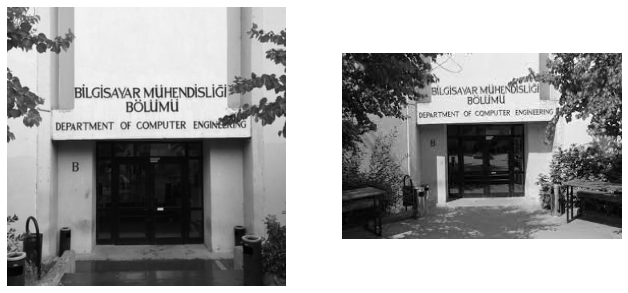

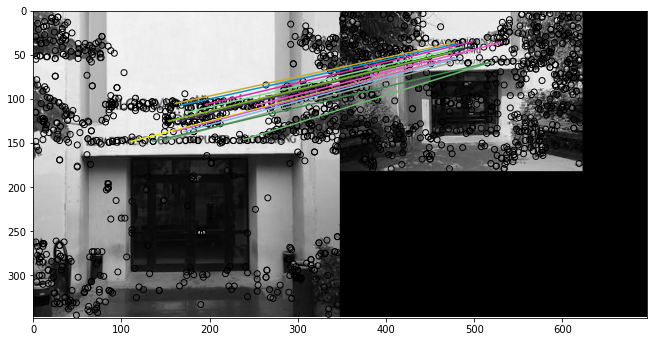

In [ ]:
# SIFT descriptor extraction and matching

#!pip uninstall scikit-image -y
#!pip install -U scikit-image
from skimage import data, io
from skimage.color import rgb2gray
from skimage.feature import match_descriptors, plot_matches, SIFT
from skimage.transform import resize
import matplotlib.pyplot as plt

image1 = rgb2gray(io.imread('bmb1.jpeg'))
image2 = rgb2gray(io.imread('bmb2.jpeg'))

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(11,8))
ax = axes.ravel()

ax[0].imshow(image1, cmap='gray')
ax[0].axis('off')
ax[1].imshow(image2, cmap='gray')
ax[1].axis('off')

# Extract SIFT descriptors
descriptor_extractor = SIFT()

descriptor_extractor.detect_and_extract(image1)
keypoints1 = descriptor_extractor.keypoints
descriptors1 = descriptor_extractor.descriptors

descriptor_extractor.detect_and_extract(image2)
keypoints2 = descriptor_extractor.keypoints
descriptors2 = descriptor_extractor.descriptors

# Find matching descriptors in two images
matches = match_descriptors(descriptors1, descriptors2, max_ratio=0.6,
                              cross_check=True)

# Plot images and mattching descriptors
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(11, 8))

plot_matches(ax, image1, image2, keypoints1, keypoints2, matches)
#plt.tight_layout()
plt.show()



#### 5. Local Binary Patterns (LBP)

In the low low level human visual system of the eye-brain channel, there is a process, called center surround mechanism, which takes differences between a central focal point and its surrounding locations. There are many computational models, which mimics the center surround mechanism to model the variations among the pixels. Local Binary Patterns  (LBP) encode the difference between a central pixel and its surrounding neighbors in a predefined circular sequence to generate  a simple texture feature. When the brightness value of the central pixel is less than its neighbor, the corresponding entry of the LBP feature vector takes the value 1, otherwise it takes the value of 0. 

Mathematically,  suppose that we define a  window in an image of size $M\times M$ to extract a texture feature. Suppose also that we define a $d$-neighborhood system. Then, in this window, for each pixel with the brightness value, $p$, we create a d-bit number, called LBP number,

$$LBP = b_0....b_{d-1},$$

where 

$$b_i = \begin{cases} 1 \quad for \ p_i\gt p_j\\0  \quad o.w\end{cases}.$$

We can compute LBP number for each pixel in an $M\times M$ texel and compute the histogram of the LBP numbers. The histogram of the LBP numbers represent the LBP pattern for that texel.



 


**Example:** Consider a pixel centered in a $3\times3$ window, as shown in Figure 46. Find the LBP number of this pixel

**Answer:** Starting from the left neighbor of the center pixel and traversing in clockwise direction, we obtain the  LBP number as,

$LBP = 01011000 = 88$

<figure><p align="center"><img src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W14/LBP.png" height=200px><figcaption>

Figure 46: LBP feature vector (right) extracted for a central pixel of the image patch (left) in an 8-neighborhood system.</figcaption></p></figure>




 
LBP texture feature is very popular for a large variety of texture analysis and classification problems, specifically in face detection.  It is very fast and efficient for real time processing of images. It is also very  robust to changes of illumination and noise.  There are many variants of LBP features in the image processing literature, which are adopted in a wide range of applications, such as medical image analysis and remote sensing..
							 	

## 2. Whole Image Representation

The feature extraction methods mentioned above explore a prescribed set of low-level visual properties of images. For example, SIFT descriptors extract the salient points which may correspond to  some informative boundary pixels. Similarly, Gabor filters  extract predefined types of textures or  smoothing filters blur the image. These representations rather resemble the low level vision tasks in the eye-brain channel. Although they are very successful in applications, such as quality control of a production line or detecting simple objects on a smooth background, they fall short to represent high level vision tasks, such as representation of content of an image. For example, we may search for the content of the image to search a particular set of objects. These types of tasks require whole image representation methods using relatively higher abstraction levels.

In the following subsections, we overview popular methods for low-level and high level representation of whole images.


### Low Level Representations of Whole Images

We have already seen some low-level whole image representation methods, such as filtering, color or edge histograms, which  are simple, yet effective for extracting low level information from the images. For example, color histograms can successfully discriminate outdoor and indoor images by seeking the modes of the blue colors, which correspond to sky or sea. 

Instead of using the entire image for extracting the  global features, such as histograms, we can partition an image into a set of regions $\{R_i\},$ then, we can extract features from each individual region. 

A segmentation algorithm partitions the image into homogenous regions with respect to a homogeneity predicate. Using this partition it is possible to describe each region by a variety of local features, mentioned in the previous sections. Then, the features of each region can be used to detect objects of interest or to assign labels to the regions.

As an example; suppose that our problem is to retrieve images from the Internet, based on its content. This set of problems are called Content Based Image Retrieval (CBIR). For example; we need to retrieve the images which contain the sky. As a first step, we segment the images and extract the color histogram of each region. Then, we detect the regions which correspond to blue color. If these regions are located in the upper half of the image and their size is above a predefined threshold, then, we decide that the corresponding image contains sky. It is possible to design segmentation based algorithms with some simple heuristics to detect objects, such as roads, trees or rocks, which can be characterized by their color or texture, as shown in Figure 47.

<figure><p  align="center"><img  src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W14/image84.png"  height=300px><figcaption>Figure 47: Segmentation maps obtained using the histograms of the HSI (Hue, Saturation and Intensity) color values of their pixels. Each row represents the segmentation map of images which contain rock, tree, road. </figcaption></p></figure>


Instead of using a segmentation algorithm, we can directly  partition an  image  into overlapping or non overlapping windows with fixed or variable sizes. Then, we can  extract features from each window. This approach reduces the computational complexity of the image processing algorithms, specially, when the size of the image is large.  Selection of the size of the window depends on the resolution of the image and the application domain. We can select relatively larger windows for  smooth images compared to textured images. Figure 48 shows examples of tiled satellite images with different window sizes.

<figure><p  align="center"><img  src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W14/image128.png"  height=350px><figcaption>Figure 48: Multi-spectral LANDSAT scenes of Washington DC (left) and southern British Columbia and Washington State (right) that are divided into smaller tiles for easier processing. The first scene (5,376x6,656; 205MB) is divided into 104 tiles and the second one (7,680x10,240; 450MB) is divided into 300 tiles. The best tile size for each scene is automatically determined by the system. (From Selim Aksoy)</figcaption></p></figure>


A similar CBIR system can be designed without segmentation. This time we can use tiled representation and extract features from each tile. Figure 49 shows an image with tiled representation for retrieving the images, which contain the sky.


<figure><p  align="center"><img  src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W14/image72.png"  height=300px><figcaption>Figure 49: Dividing an image into 5x7 fixed size non-overlapping grid cells, generated by a CBIR system. The system successfully brings  the images with sky, when the number of tiles with blue colors residing in the upper half of the image, exceeds a certain threshold. (From Selim Aksoy)</figcaption></p></figure>


The above heuristic methods are successful only when the  visual information can be described by low level image features. Unfortunately, these methods fall short for the image processing problems, which cannot be described by low level numerical feature vectors. For example; it is not possible to represent hierarchical relationships in a satellite image, to represent the information such as “buildings are contained in cities” or “trees are located in forests”. Further abstraction levels of visual information is needed to  represent this type of visual information, as described below. 

### High Level Representations of Whole Images

Suppose that we partition an image into  N- regions. These regions can be defined as the homogenous regions obtained at the output of  a segmentation map or a tiled representation obtained by partitioning the image into a grid. In both cases, an image can be represented in terms a collection of mutually exclusive and collectively exhaustive regions, 

$$f(x,y) =\bigcup_{i=1}^N R_i.$$

The high level relations among these regions, such as, “region $R_i$ is contained in region $R_j$”  or region “$R_i$ is adjacent to  region $R_j$” can be represented by using trees, relational  graphs or attributed graphs.



#### Tree Representation of Images

Consider the satellite image and its segmentation map given in Figure 50. There is a hierarchical relation among these regions. The image consists of two major classes, namely the sea and the land. The land consists of two subclasses, namely, the port and the jetties.  



<figure><p  align="center"><img  src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W14/satellite.png"  height=300px><figcaption>Figure 50: A satellite image and its segmentation map. The regions in the segmentation map have hierarchical relations. </figcaption></p></figure>




The above hierarchical relations among the image regions can be successfully represented by tree data structures.  

Mathematically speaking, given N-regions of an image, $\{R_i\}_{i=1}^N$, we define a tree data structure with $L$-levels, among these regions, as follows;
 
$$T = \{V_k, A_{k}\},$$
 
where $V_k$, is the set of nodes at level $k$, and $A_{k}$ represents the set of relations between the parent node at level $k$  and its children  nodes for $k= 0,...(L-1)$. The root of the tree, at level 0, may correspond to the entire image or a specific region of the image which correspond to the object of interest. As we move towards the leaves of the tree, the regions, $\{R_i\}$ of the image are represented in the nodes, $v_{ik}\in V_k$, with respect to a predefined hierarchical relation. Thus, the  tree data structure organizes the relations among all the regions of the image represented by the set of nodes, $V_k= \{v_{ik}\}$.  The definition of the set of relations, $A_{k}$, depends on the application. For example; some objects can have holes and, also, may consist of multiple parts that are not contiguous, as shown in Figure 51. In order to represent this type of  objects in a tree data structure, the set of relations, $A_{k}$ between the parent and children nodes  are defined as “contains '', as shown in Figure 51. 
 
 
<figure><p  align="center"><img  src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W14/image74.png"  height=250px><figcaption>
 
Figure 51: Representation of the relations among the regions of a binary  image with a tree data structure. The  white object consists of isolated regions and holes. The root of the tree is the whole image. The relation between the level of the tree is $A_{k}$ is “contains”. </figcaption></p></figure>

Another example is given in Figure 52 to represent a composite region by a  tree structure. In this case, the relations between the parent and children nodes can be defined as “surrounds”.

<figure><p  align="center"><img  src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W14/image85.png"  height=250px><figcaption>Figure 52: (a) A simple composite region. (b) Tree representation obtained by using the relationship "inside of". (From Gonzales and Woods)</figcaption></p></figure>


Quadtree representation that we have seen in Chapter 8 is another example of tree data structure, where there are always four children of each parent region. In this case, the relation between the parent node and its children “split the parent region into four subregions until the children are homogeneous with respect to a homogeneity predicate”. Figure 53 shows the result of a splitting algorithm for generating the quad tree of Figure 54.

<figure><p  align="center"><img  src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W14/quad2.png"  height=300px><figcaption>Figure 53: Splitting the image into regions until each region is homogeneous. </figcaption></p></figure>

<figure><p  align="center"><img  src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W14/quad1.png"  height=300px><figcaption>Figure 54: Building the quad tree based on the splitting algorithm.  </figcaption></p></figure>

The result of the splitting algorithm consists of many small regions. A post processing algorithm is required to merge the spatially adjacent homogeneous regions in the quad tree, as shown in Figure 55.

<figure><p  align="center"><img  src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W14/quad3.png"  height=200px><figcaption>Figure 55: Merging the regions obtained as the nodes of quad tree. The adjacent regions of the image in the left fall apart in the generated quad tree. A post processing algorithm is used to merge  the regions iteratively to obtain the contiguous regions of the image obtained in the middle and right. </figcaption></p></figure>

### Graph Representation of Images

In many practical problems the relations among the regions may not be hierarchical. In such cases it is more convenient to use a graph data structure to represent the relations.

Mathematically speaking, given N-regions of an image, $\{R_i\}_{i=1}^N$, we define a graph with a set of nodes $V$ and a set of edges, $E$, as follows;
 
$$G = \{V, E\},$$
 
where each node, $v_i\in V$ corresponds to a region $R_i$, and an edge $e_{ij}\in E$ represents the relation between nodes $v_i\in V$ and $v_j\in V$ . The definition of relations between the regions depends on the application domain. Note that the set of edges form an $N\times N$ matrix, where each entry has the value of the relation,  $e_{ij}.$


#### Region Adjacency Graphs
 
A popular graph in image processing is called  **Region Adjacency Graph (RAG)** in which each node represents a region of the image and an edge connects two nodes if the regions are adjacent. Figure 56 shows the output of a segmentation map and the corresponding RAG. Note that the edge matrix, called the region adjacency matrix, has binary entries. When two regions $R_i$ and $R_j$ are adjacent, the corresponding edge weight $e_{ij} = 1,$ otherwise it is 0.


<figure><p  align="center"><img  src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W14/image116.png"  height=300px><figcaption>Figure 56: Segmentation map of a simple image and its corresponding RAG. (From Selim Aksoy) </figcaption></p></figure>

Region adjacency graphs are very helpful for detecting some objects in an image. As an example, consider the image of  Figure 58 and the corresponding RAG. If our goal is to detect the regions corresponding to the boat object, we search for the nodes, which are adjacent to the sea object. Sea is relatively easy to detect compared to the boat object because of the typical blue color and large size of the region. Thus, searching for the regions adjacent to the sea object provides clues about the labels of the nodes adjacent to the sea object, such as boat, forest or beach.

<figure><p  align="center"><img  src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W14/image117.png"  height=200px><figcaption>Figure 57: (From Selim Aksoy)</figcaption></p></figure>


<figure><p  align="center"><img  src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W14/image124.png"  height=350px><figcaption>Figure 58: An image with boundary overlay and the corresponding RAG.  (From Selim Aksoy)</figcaption></p></figure>



####  Attributed Relational Graphs

 Another popular class of graphs used in image processing is   the **Attributed relational graphs (ARG)** .  This class of  graphs generalizes the  ordinary graphs, defined above  by attaching discrete or continuous features (attributes) to the vertices and edges.

Mathematically, an attributed relational graph $G$  is a four-tuple,

 $$G=(V, E, f_v, f_e),$$ 

where each node $v_{i}\in V$ is mapped to a label $L_{v_i}$ by a function 

$$f_v : v_i \rightarrow L_{v_i},$$

and each edge $e_{ij}\in E$ is mapped to a label $L_{e_{ij}}$ by another function, 

$$f_e : e_{ij} \rightarrow L_{e_{ij}}.$$



The attributed graphs are widely used in many application domains of image processing, such as remote sensing. For example, Figure 59 shows a small window of  a segmentation map, where function, $f_v$ maps  the nodes  to the label of the regions, namely, water (blue), city center (red), residential area (brown) and park (green). The function $f_e$ maps the edges to the membership values of some spatial relations, namely, near below, near right, surrounded by and bordering right. 



<figure><p  align="center"><img  src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W14/image125.png"  height=400px><figcaption>Figure 59: ARG for an example scene (marked with a white rectangle) containing regions classified as water (blue), city center (red), residential area (brown) and park (green). Nodes are labeled using region id, class id, class probability (in parenthesis) and edges are labeled using relationship names and membership values (in parenthesis).(From Selim Aksoy)</figcaption></p></figure>

It is possible to define sophisticated relations between the regions of an image. A good example is given in Figure 60, where the ARG of the boundary overlay, obtained at the output of a segmentation algorithm  LANDSAT scene, is given. The nodes of the ARG are mapped to the coordinates of the centroid of each region.  Nodes are located at the centroids of the corresponding regions. Edges are drawn between the noded, when the distance between the nodes is less than 10 pixels. This relation connects only small regions to merge them into one region to smooth the noise or textural structures.

<figure><p  align="center"><img  src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W14/image134.png"  height=400px><figcaption>Figure 60:ARG of a LANDSAT scene. Nodes are located at the centroids of the corresponding regions. Edges are drawn only for pairs that are within 10 pixels of each other to keep the graph simple. (From Selim Aksoy)</figcaption></p></figure>



**Motivating Question**: How can we compare the similarities of two images using ARG?

There is an extensive literature which defines graph similarities. One possible answer to the above question is to use **editing distance** between two ARGs. Loosely speaking, edit distance is  defined as the minimum cost taken over all sequences of operations (error corrections such as substitution, insertion and deletion) that transform one ARG to the other.

<figure><p  align="center"><img  src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W14/image130.png"  height=400px><figcaption>Figure 61:  Find the ARG of the area of interest (query). (From Selim Aksoy)</figcaption></p></figure>

<figure><p  align="center"><img  src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W14/image137.png"  height=400px><figcaption>Figure 62:Search the graph for the whole scene. (From Selim Aksoy)</figcaption></p></figure>

<figure><p  align="center"><img  src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W14/image135.png"  height=400px><figcaption>Figure 63: First find the nodes (regions) with similar attributes (From Selim Aksoy)</figcaption></p></figure>

<figure><p  align="center"><img  src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W14/image140.png"  height=400px><figcaption>Figure 64: First find the subgraphs with similar edges (relationships). (From Selim Aksoy)</figcaption></p></figure>

Many real-world problems  can be represented as an ARG. For example, a visual scene can be modeled as the composition of the objects with specific spatial/attribute relationships. Molecular compounds can be represented as an ARG with atoms as vertices and bonds as edges. A web site can be represented as an ARG with web pages as vertices and URL links as edges.



<figure><p  align="center"><img  src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W14/image141.png"  height=300px><figcaption>Figure 65: Human visual system</figcaption></p></figure>

<figure><p  align="center"><img  src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W14/image142.png"  height=400px><figcaption>Figure 66: Learning the numbers. </figcaption></p></figure>

<figure><p  align="center"><img  src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W14/image144.png"  height=300px><figcaption>Figure 67: Learning the numbers. </figcaption></p></figure>


